In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/smartcart_customers (1).csv")
df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
897,5046,1958,Graduation,Divorced,78331.0,0,1,23-01-2014,97,756,...,160,169,61,2,10,6,7,4,0,0
657,946,1958,2n Cycle,Together,26490.0,0,0,22-09-2012,92,45,...,21,20,25,2,3,1,5,6,0,0
668,11007,1968,PhD,Married,29187.0,1,0,09-05-2013,43,26,...,0,0,2,1,1,0,3,8,0,0
1641,1665,1964,PhD,Divorced,64140.0,0,2,23-09-2013,71,1459,...,0,15,215,5,2,5,6,5,0,1
208,868,1966,Graduation,Married,44794.0,0,1,08-06-2014,99,54,...,0,0,4,1,2,0,3,6,0,0


In [3]:
df.shape

(2240, 22)

In [4]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# Data Preprocessing

In [5]:
## Handle Missing Values

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engineering

In [8]:
# Age
df["Age"] = 2026 - df["Year_Birth"]

In [9]:
# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
reference_date = df['Dt_Customer'].max()
print(reference_date)

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days


2014-06-29 00:00:00


In [10]:
# Spending
df['Total_Spending'] = df['MntFishProducts'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntSweetProducts'] + df['MntWines']


In [11]:
# Children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']


In [12]:
## Education
df['Education'].value_counts()
df['Education'] = df['Education'].replace({
    'Basic':'Undergraduate','2n Cycle':'Undergraduate',
    'Graduation':'Graduate',
    'Master':'Postgraduate',
    'PhD':'Postgraduate'

})
df['Education']

,Education
0,Graduate
1,Graduate
2,Graduate
3,Graduate
4,Postgraduate
...,...
2235,Graduate
2236,Postgraduate
2237,Graduate
2238,Postgraduate


In [13]:
# Marital Status
df['Living_With'] = df['Marital_Status'].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

# Drop Columns

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1529,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,21,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,734,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,48,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,407,1,Partner


In [15]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [16]:
df_cleaned.shape

(2240, 15)

In [17]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,21,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,734,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,48,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,407,1,Partner


# Outliers

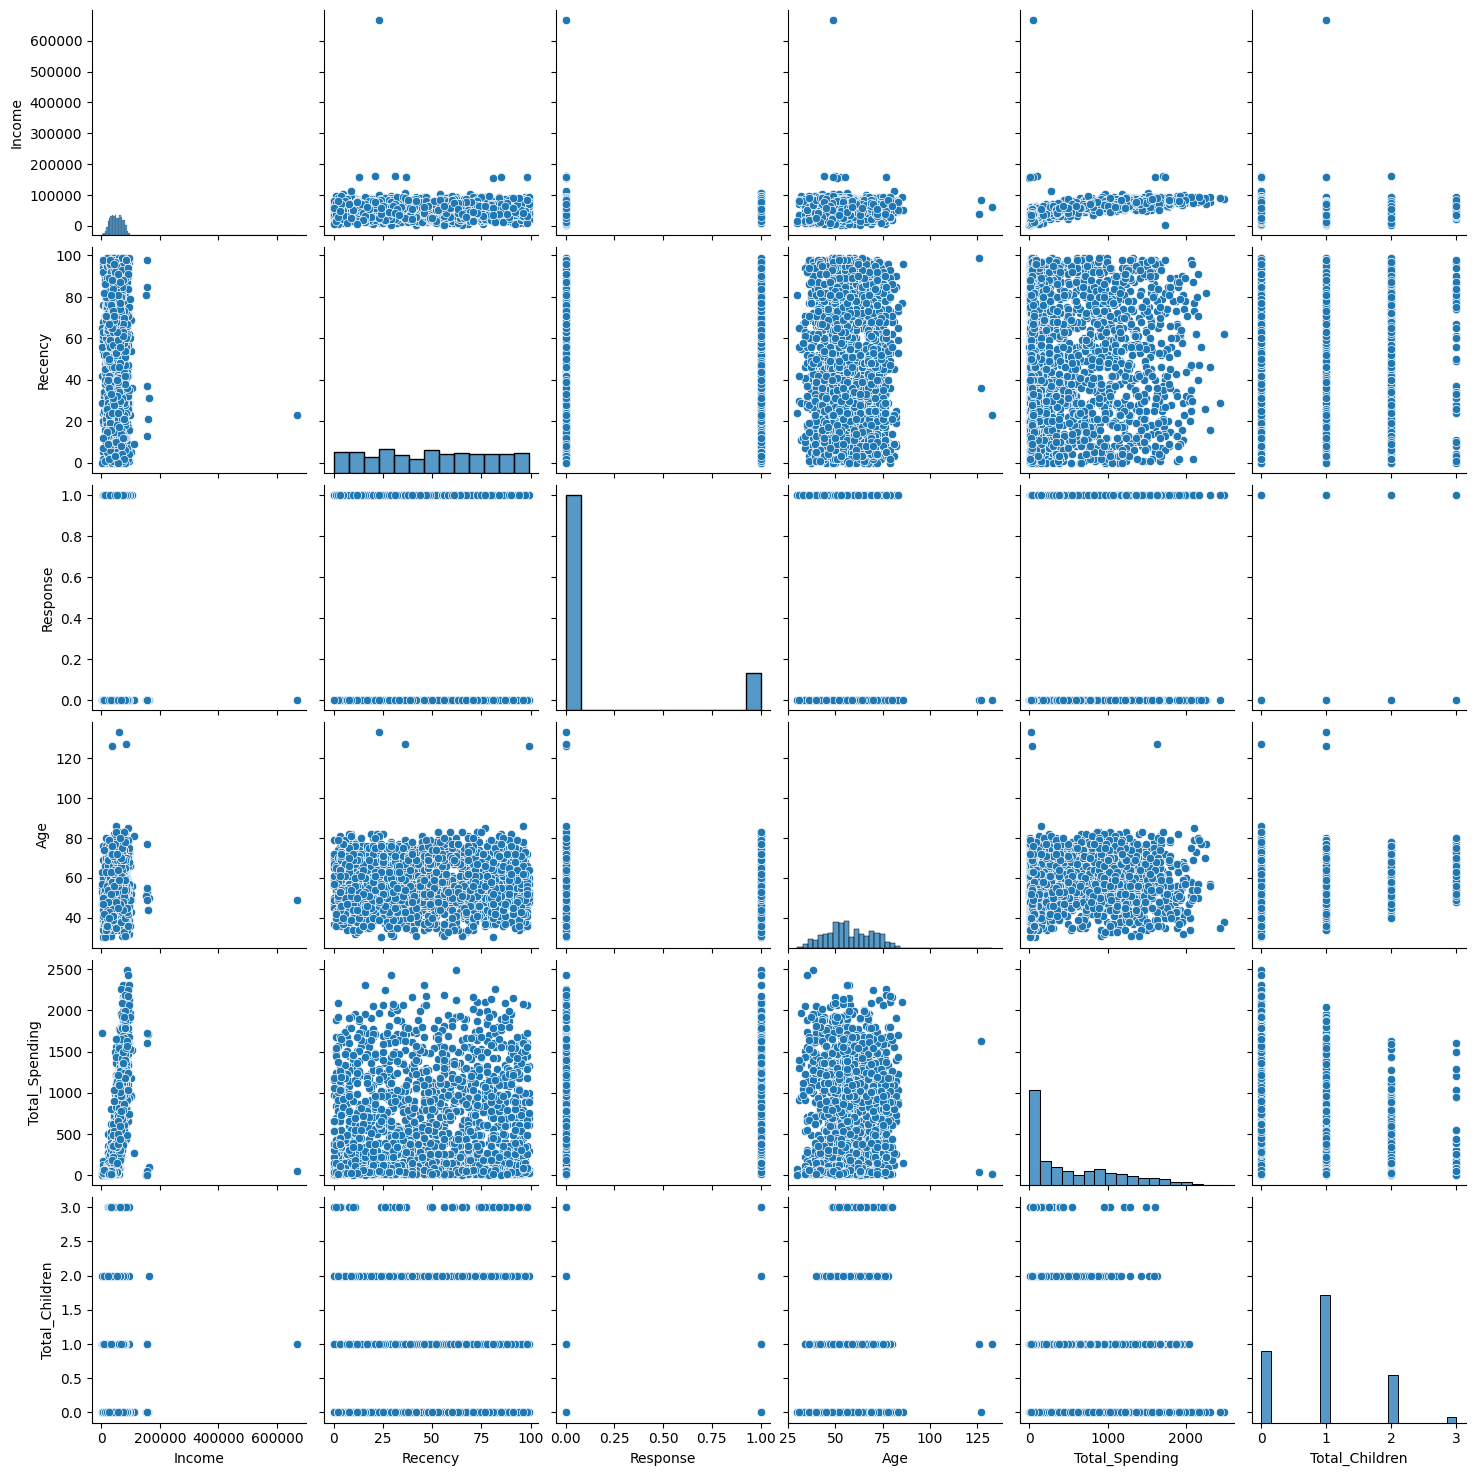

In [18]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# relative plots of some features-  pair plots
sns.pairplot(df_cleaned[cols])

In [19]:
# Remove outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


# Heatmap

<Axes: >

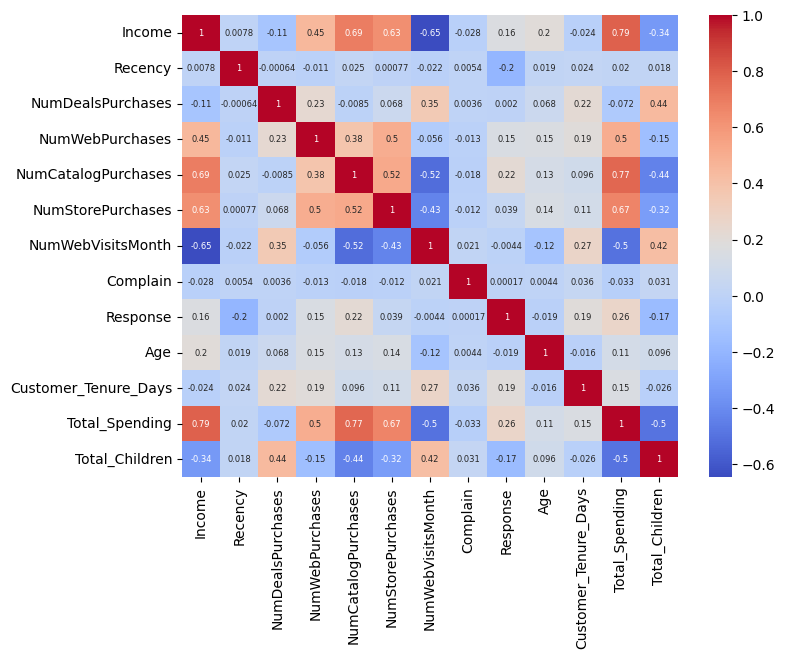

In [20]:
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

In [21]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,21,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,734,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,48,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,407,1,Partner


In [22]:
from sklearn.preprocessing import OneHotEncoder

In [23]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [24]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)


In [25]:
df_encoded.shape

(2236, 18)

In [26]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,21,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,734,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,48,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,407,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
X = df_encoded

In [29]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualize

In [30]:
X_scaled.shape

(2236, 18)

In [31]:
# 2D
from sklearn.decomposition import PCA

In [32]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [33]:
pca.explained_variance_ratio_

array([0.23125129, 0.11385768, 0.10407016])

Text(0.5, 0.92, '3d projection')

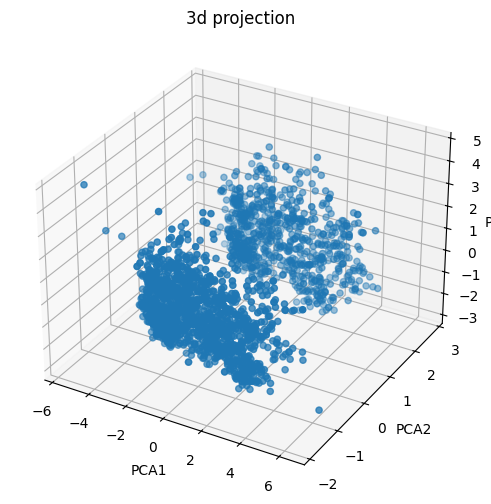

In [34]:
# plot
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Analyze K value

1. Elbow Method

In [35]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)


In [36]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [37]:
print("best k =", optimal_k)

best k = 4


Text(0, 0.5, 'WCSS')

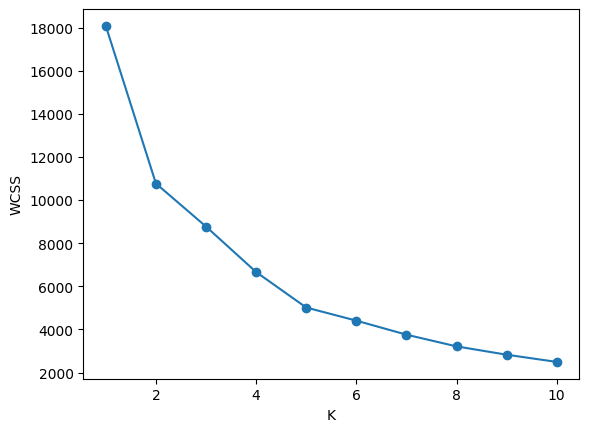

In [38]:
# plot

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

2. Silhouette Score

Text(0, 0.5, 'Silhouette score')

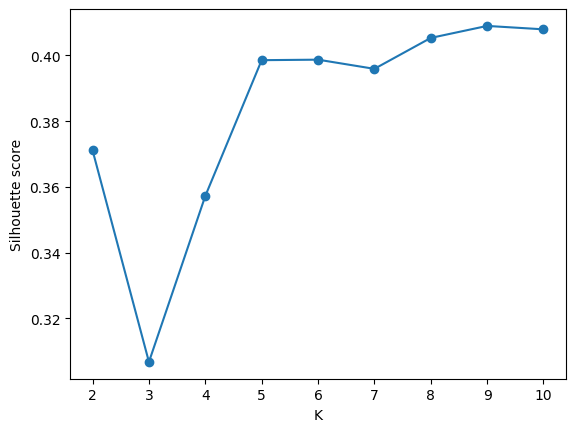

In [39]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

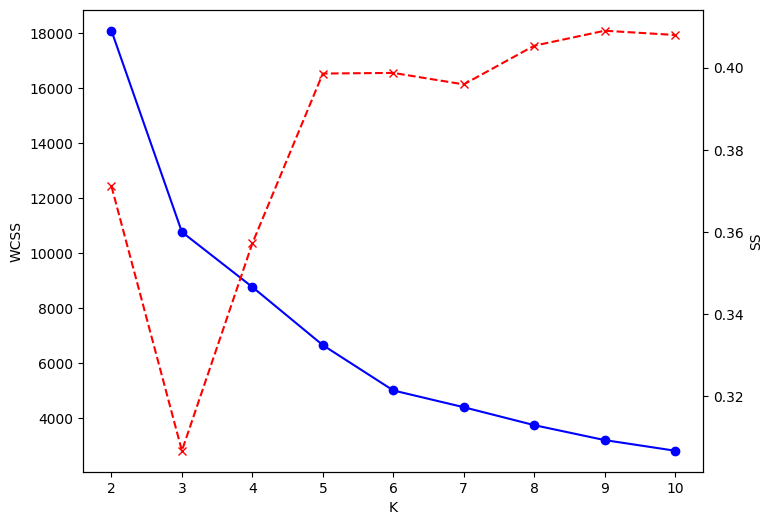

In [40]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

In [41]:
# K_means

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

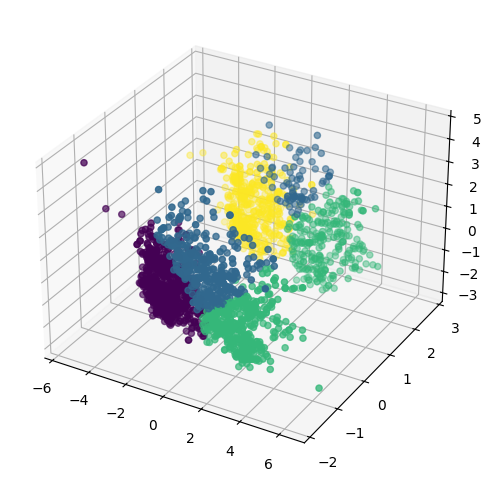

In [42]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [43]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [44]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

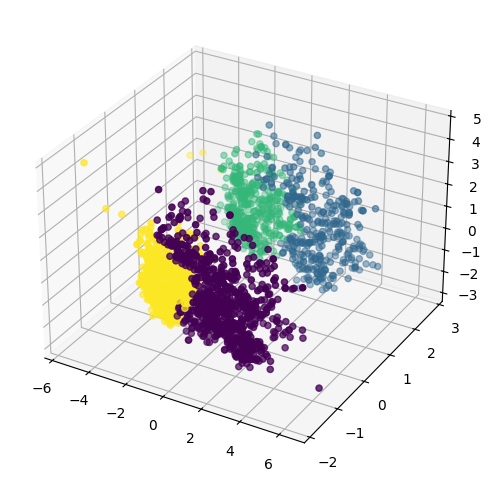

In [45]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

In [46]:
X["cluster"] = labels_agg
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,1.0,0.0,0.0,1.0,0.0,1
1,46344.0,38,2,1,1,2,5,0,0,72,113,21,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,734,0,1.0,0.0,0.0,0.0,1.0,0
3,26646.0,26,2,2,0,4,6,0,0,42,139,48,1,1.0,0.0,0.0,0.0,1.0,3
4,58293.0,94,5,5,3,6,5,0,0,45,161,407,1,0.0,1.0,0.0,0.0,1.0,3


<Axes: xlabel='cluster', ylabel='count'>

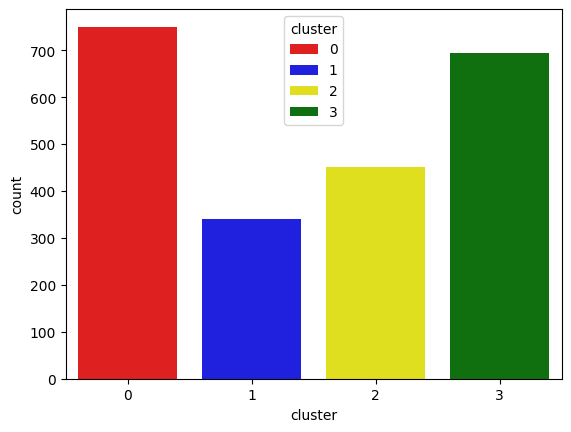

In [47]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

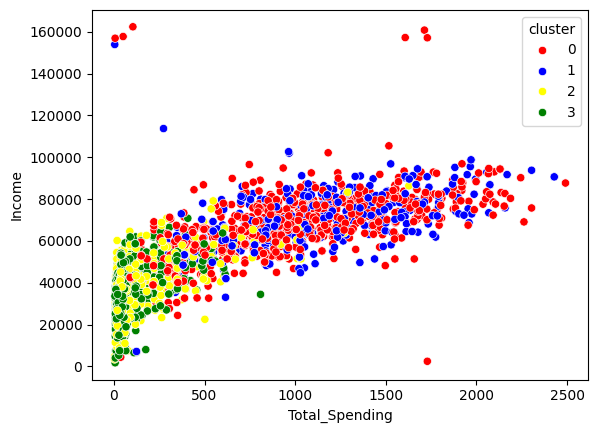

In [48]:
# Income & Spending patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [49]:
# Cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        67291.757333  49.062667           2.460000         5.625333   
1        70458.914706  50.088235           1.908824         5.761765   
2        38551.119734  48.669623           2.465632         2.855876   
3        35042.648921  48.988489           2.294964         2.408633   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   4.532000           8.021333           4.153333  0.006667   
1                   5.055882           8.314706           3.682353  0.005882   
2                   0.935698           3.893570           6.443459  0.011086   
3                   0.597122           3.395683           6.647482  0.011511   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         